# Airbnb Pricing Prediction
## MSE446 Final Project
### Exploratory Data Analysis

The purpose of this EDA is to understand the main patterns in our dataset before modelling. In particular, we want to examine how listing characteristics, amenities, time-related variables, and external factors relate to the average nightly price, and identify any redundancy or potential leakage among the features.

In [16]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("MSE446_cleaned_dataset.csv")

In [18]:
df["date"] = pd.to_datetime(df["date"])
# Data Set Overview 
print("Dataset Shape:")
print(df.shape)

print("\nColumn Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.head()

Dataset Shape:
(3236, 124)

Column Types:
listing_id                                           int64
date                                        datetime64[us]
vacant_days                                          int64
reserved_days                                        int64
occupancy                                          float64
                                                 ...      
cancellation_policy_Flexible                         int64
cancellation_policy_Limited                          int64
cancellation_policy_Moderate                         int64
cancellation_policy_Strict                           int64
cancellation_policy_Super Strict 30 Days             int64
Length: 124, dtype: object

Missing Values:
listing_id       0
date             0
vacant_days      0
reserved_days    0
occupancy        0
revenue          0
rate_avg         0
photos_count     0
superhost        0
latitude         0
dtype: int64

Duplicate Rows:
0


,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,photos_count,superhost,latitude,...,listing_type_Private room in home,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days
0,4925824,2025-02-01,28,0,0.0,0,36.3,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
1,4925824,2025-03-01,31,0,0.0,0,35.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
2,4925824,2025-04-01,30,0,0.0,0,35.9,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
3,4925824,2025-05-01,31,0,0.0,0,36.0,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
4,4925824,2025-06-01,30,0,0.0,0,36.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0


### Dataset Overview

Checking the dataset shape, column types, missing values, and duplicate rows to confirm that the cleaned dataset is ready for exploratory data analysis. This gives a quick overview of the structure of the data and helps verify that no major data quality issues remain before modelling.

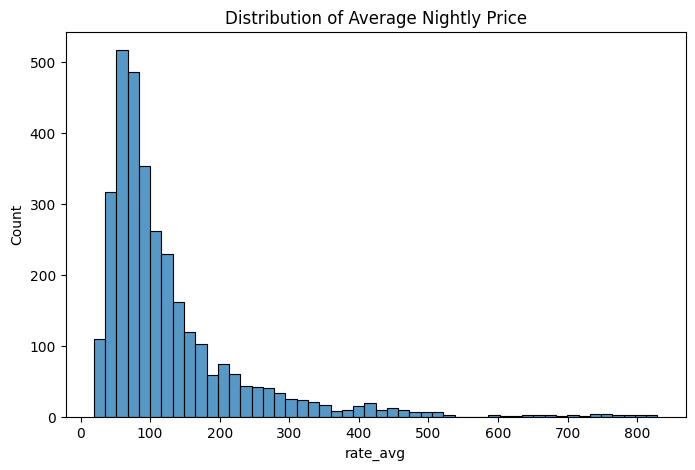

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["rate_avg"], bins=50)
plt.title("Distribution of Average Nightly Price")
plt.xlabel("rate_avg")
plt.show()

### Distribution of Average Nightly Price

Starting off with a histogram to show the distribution of listing prices across the dataset, we can see that most listings fall within the $50 to $150 range.

The distribution is right-skewed, with a long tail extending towards higher prices, which suggests the presence of a smaller number of high-priced listings (outliers).

This is important because skewness in the target variable can impact model performance, especially for linear regression. We may consider a transformation (such as log(price)) in modelling to decrease the effect of these more-"extreme" values.

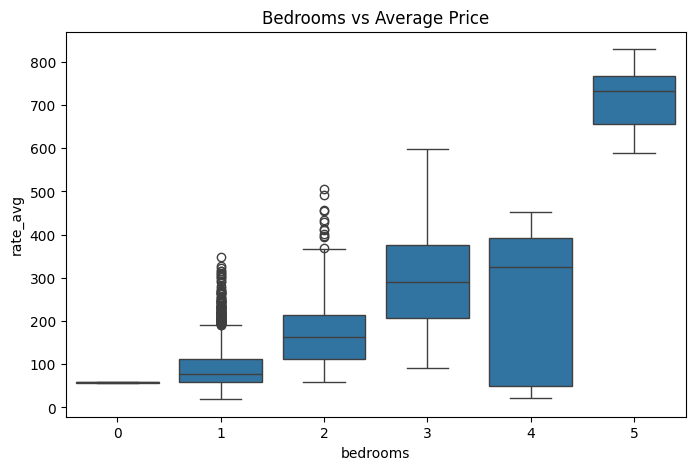

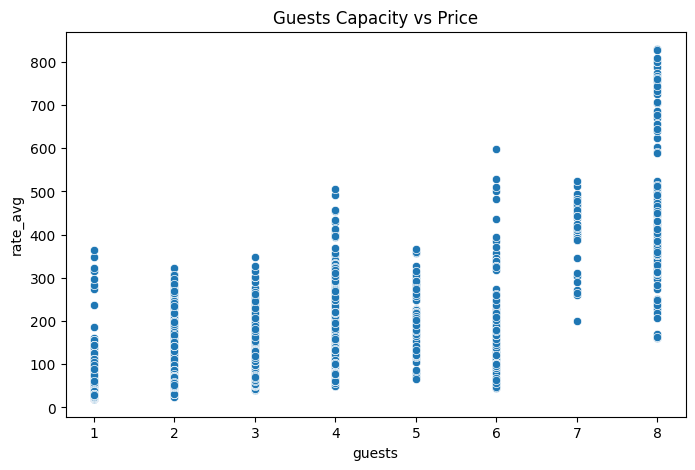

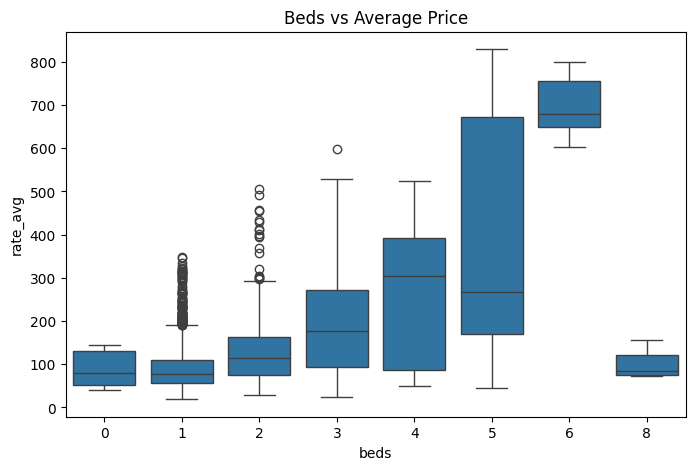

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["bedrooms"], y=df["rate_avg"])
plt.title("Bedrooms vs Average Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["guests"], y=df["rate_avg"])
plt.title("Guests Capacity vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=df["beds"], y=df["rate_avg"])
plt.title("Beds vs Average Price")
plt.show()

### Listing Size Features vs Price

These plots examine how listing size features (bedrooms, guest capacity, and number of beds) relate to the average price.

Overall, we can clearly observe a positive relationship. As the size and capacity of a listing increase, the average nightly price also tends to increase. Listings with more bedrooms and higher guest capacity generally have higher median prices and a wider range of values.

However, the variability within each category suggests that, while features related to size are important predictors of price, they are not the only factors influencing pricing.

These features are likely to be strong inputs for the predictive model, but additional variables will be needed to fully explain price differences.

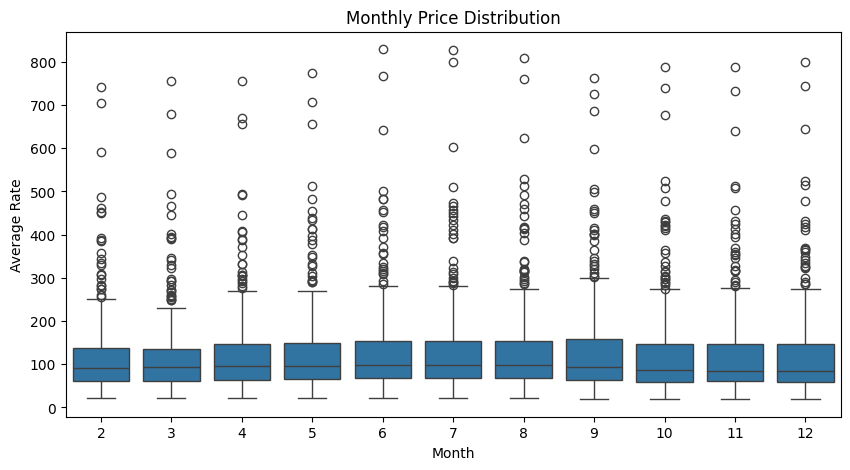

In [21]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["date"].dt.month, y=df["rate_avg"])
plt.title("Monthly Price Distribution")
plt.xlabel("Month")
plt.ylabel("Average Rate")
plt.show()


### Monthly Price Distribution

This box plot shows how listing prices vary across different months of the year. Overall, the median prices remain relatively consistent, with only a slight increase during the middle of the year (summer months).

There are some higher-priced outliers in certain months, but there isn't exactly a strong seasonal pattern in prices, which tells us that the month/time of year could have just a limited impact on pricing compared to the other features.

However, since there are small variations, month can still be included as a feature to capture any seasonal effects in the model, even if they are minor.

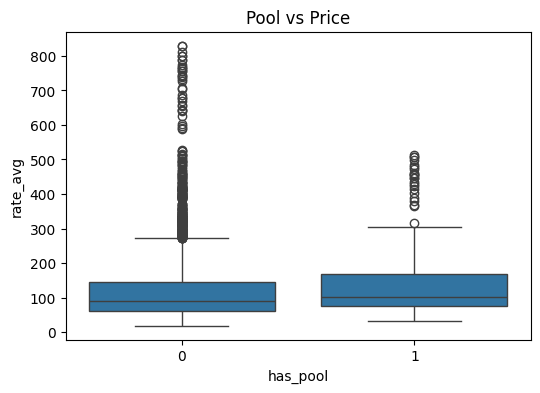

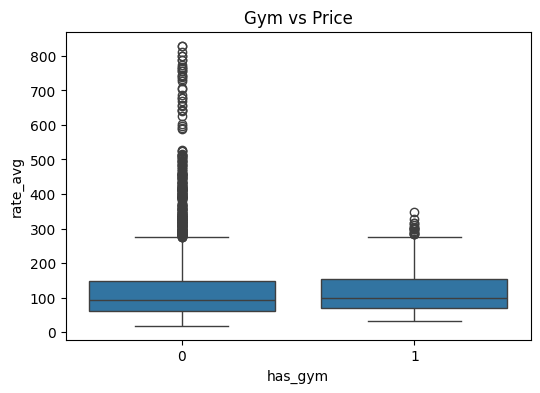

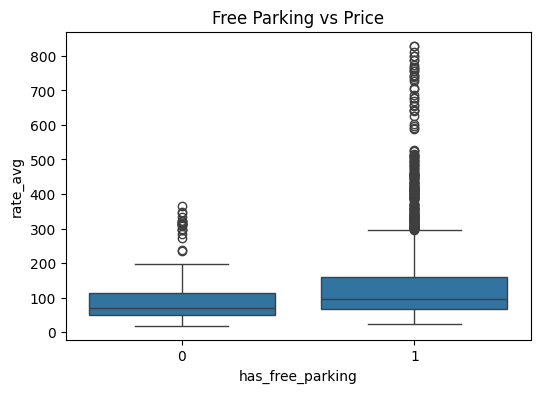

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_pool"], y=df["rate_avg"])
plt.title("Pool vs Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_gym"], y=df["rate_avg"])
plt.title("Gym vs Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df["has_free_parking"], y=df["rate_avg"])
plt.title("Free Parking vs Price")
plt.show()

### Amenities vs Price

These plots allow us to compare the effect that amenities have on listing prices (pool, gym, and free parking)

Listings that include these amenities generally have slightly higher median prices compared to those that do not. However, there is significant overlap in price distributions between listings with and without these amenities, which indicates that they are not critical or primary drivers, but still provide useful information

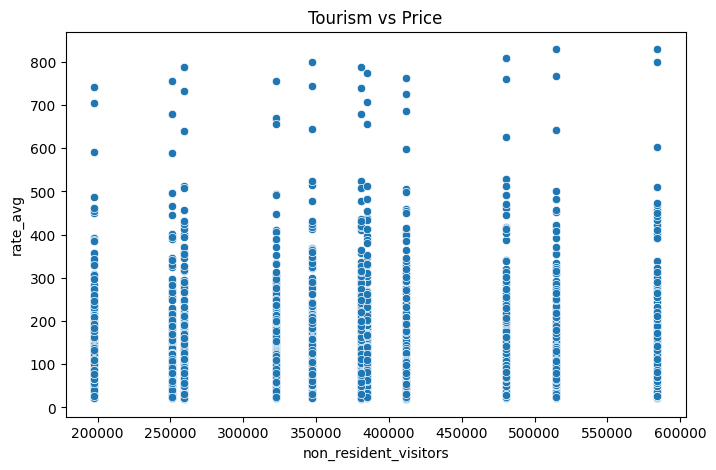

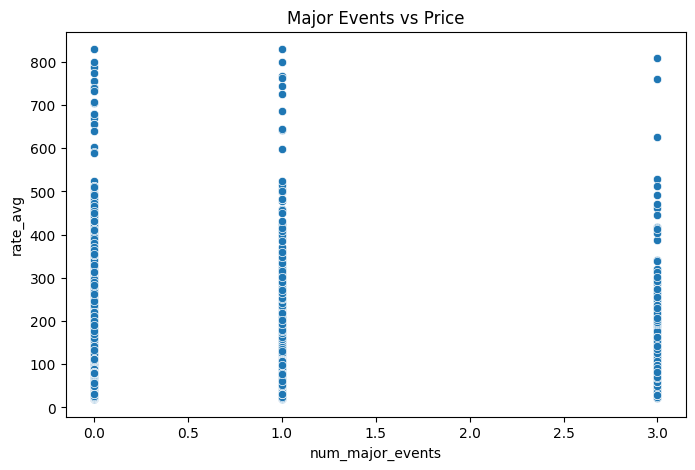

In [23]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["non_resident_visitors"], y=df["rate_avg"])
plt.title("Tourism vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["num_major_events"], y=df["rate_avg"])
plt.title("Major Events vs Price")
plt.show()

### Tourism and Events vs Price

These plots show us how/if external demand factors, such as tourism levels and major events, relate to listing prices.

There is no strong visible relationship between the number of non-resident visitors and price, as prices remain widely distributed across all tourism levels. This suggests that tourism alone may not be the best predictor for pricing.

Similarly, the number of major events shows a weak trend, with slightly higher prices in months with more events, but a lot of overlap across all categories.

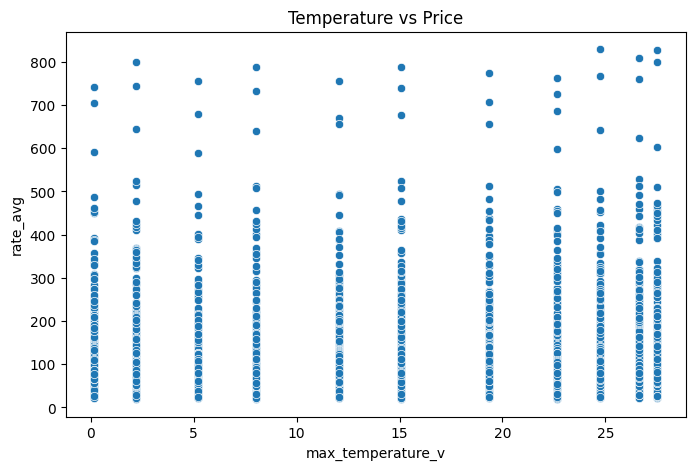

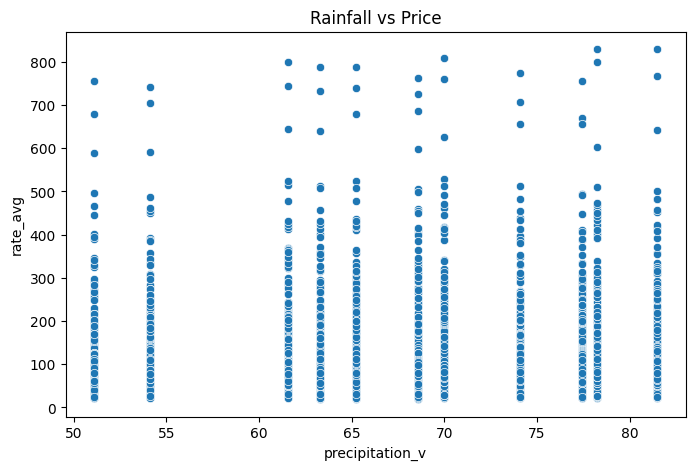

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["max_temperature_v"], y=df["rate_avg"])
plt.title("Temperature vs Price")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=df["precipitation_v"], y=df["rate_avg"])
plt.title("Rainfall vs Price")
plt.show()

### Weather vs Price

These plots explore the relationship between weather conditions (temperature and rainfall) and listing prices.

We don't see a clear relationship between temperature and price, as listings are spread across all price levels regardless of temperature. Similarly, rainfall does not show any strong pattern, with prices being widely distributed across different precipitation levels.

These weather variables could potentially capture and relate to seasonal effects, but they don't significantly influence pricing.

In [25]:
corr_target = df.corr()["rate_avg"].sort_values(ascending=False)

print("\nTop 50 Features Correlated with Price:")
print(corr_target.head(50))


Top 50 Features Correlated with Price:
rate_avg                           1.000000
ttm_avg_rate_native                0.974066
ttm_avg_rate                       0.974062
l90d_avg_rate                      0.926502
l90d_avg_rate_native               0.926488
bedrooms                           0.728454
guests                             0.720947
baths                              0.642458
ttm_revpar                         0.620521
ttm_revpar_native                  0.620055
ttm_revenue                        0.618774
ttm_revenue_native                 0.618357
beds                               0.567727
ttm_adjusted_revpar                0.517727
ttm_adjusted_revpar_native         0.517148
revenue                            0.497300
listing_type_Entire home           0.484531
cleaning_fee                       0.369838
l90d_revenue                       0.329042
l90d_revenue_native                0.329030
l90d_revpar_native                 0.326210
l90d_revpar                        0

### Correlation with Price

This output shows the features most strongly correlated with average nightly price.

Many of the features that have a strong positive correlations with price are related to listing size (bedrooms, guests, baths, and beds). This aligns with the previous visuals, confirming that larger listings tend to be more expensive. Amenities and rating-related features, or weather and tourism variables have very low correlations, reinforcing that they have a smaller impact on pricing.

There are also very high correlations with variables such as `ttm_avg_rate` and `l90d_avg_rate`. However, these are derived pricing metrics and are related to the target variable itself, so they may introduce data leakage if used in our model.

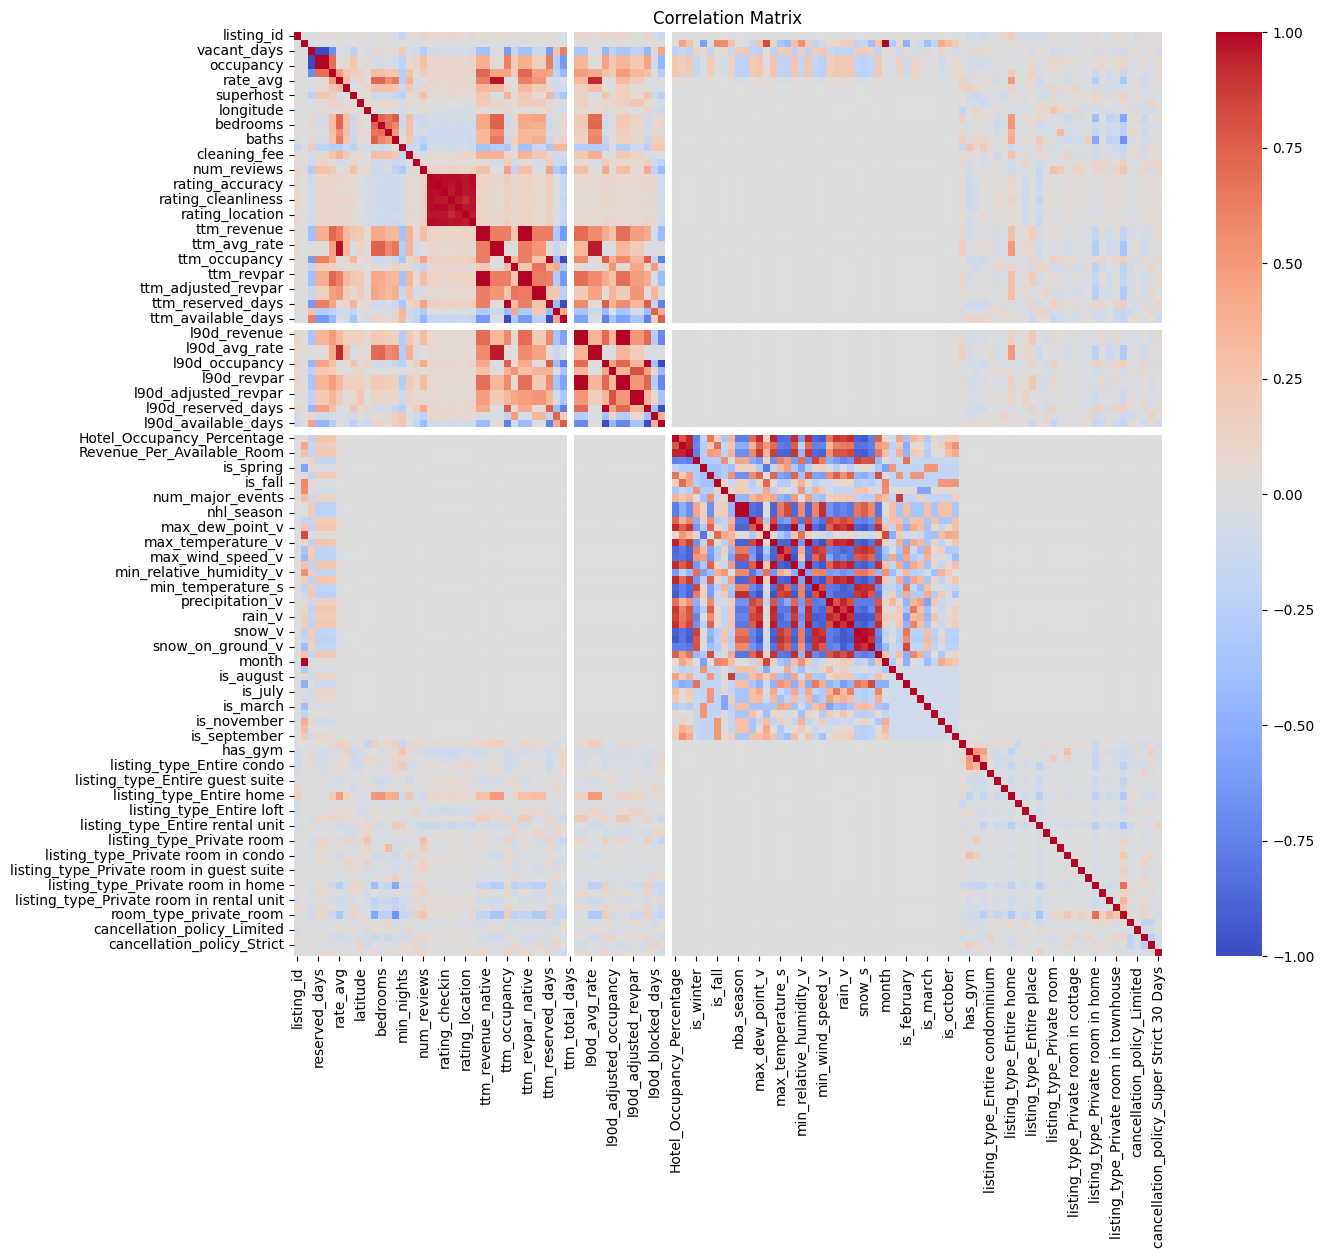

In [26]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix

This heatmap shows the pairwise correlations between all numerical features in the dataset.

Clusters of highly correlated variables are observed, particularly with pricing-related and revenue-based features. This shows some overlap (redundancy), as many of the variables capture similar information. Size-related features such as bedrooms, guests, and beds also show positive correlations with pricing variables, while weather, tourism, and some categorical variables show relatively weak correlations with most features - this all reflects what was previously observed.

This highlights potential multicollinearity in the dataset and again emphasizes the need to carefully select our features before modeling.

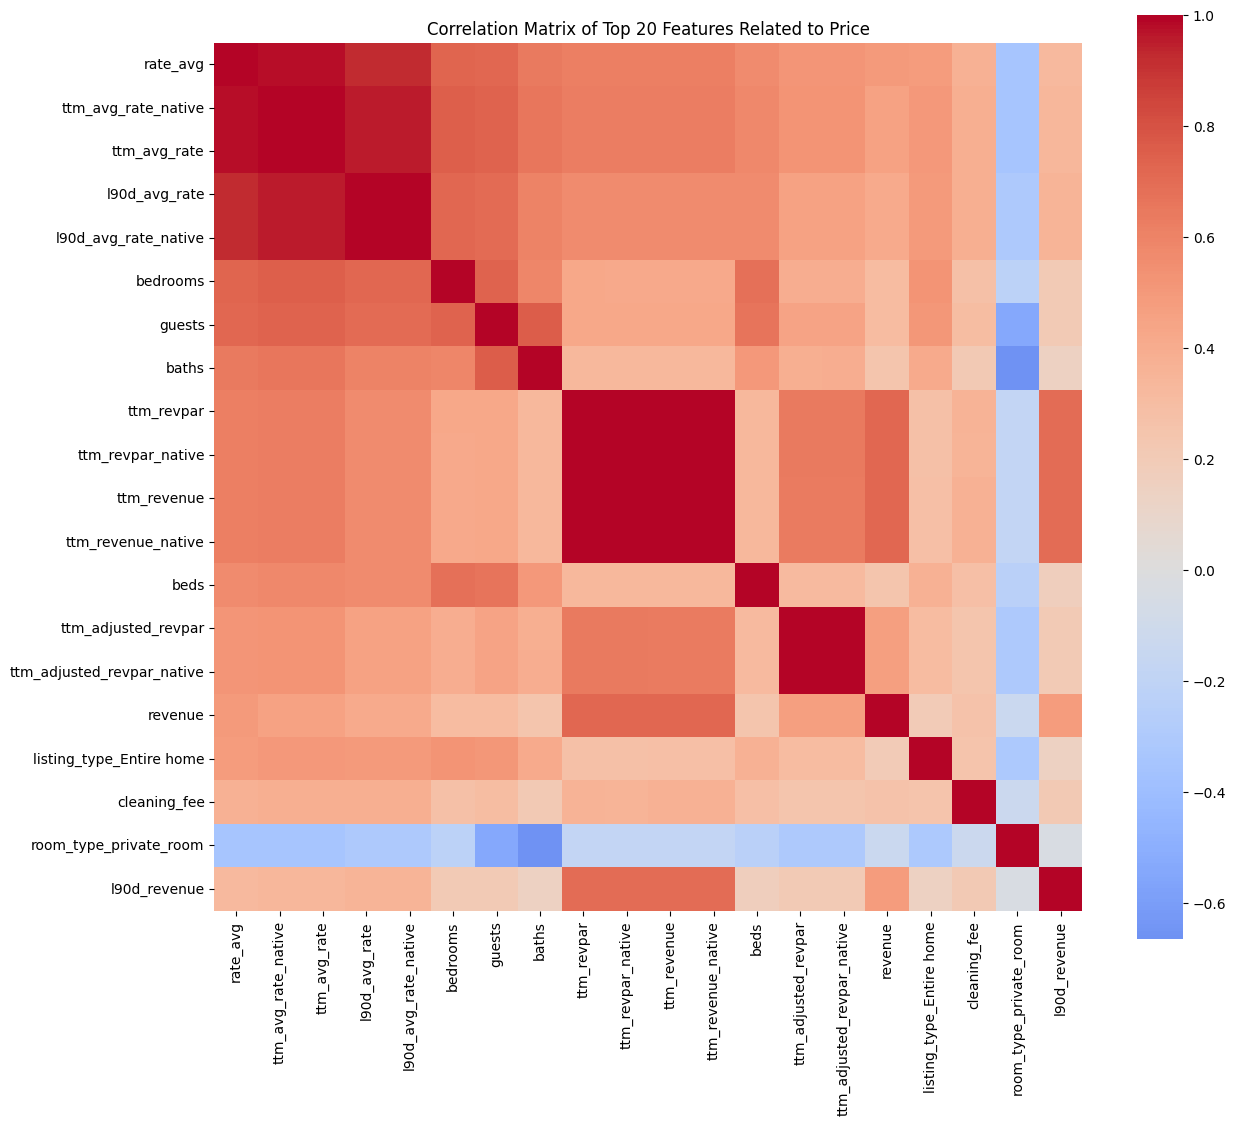

In [27]:
corr_with_target = df.corr()["rate_avg"].abs().sort_values(ascending=False)
top_20_features = corr_with_target.head(20).index
top_corr_matrix = df[top_20_features].corr()

plt.figure(figsize=(14,12))

sns.heatmap(
    top_corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Top 20 Features Related to Price")

plt.show()

### Correlation Matrix of Top Features

This heatmap focuses on the top 20 features most strongly correlated with average nightly price.

Strong positive relationships are observed between price and pricing/revenue-related metrics, such as `ttm_avg_rate`, `l90d_avg_rate`, and `ttm_revpar`, indicating that historical pricing and performance metrics are highly predictive of current prices. This again indicates redundancy.

Interestingly, features like `cleaning_fee` and certain listing types (e.g., entire home) are positively associated with price, while private room listings show a negative correlation.

In [28]:
import numpy as np  

corr_matrix = df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool) 
)

high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print("\nHighly Correlated Features (>0.9):")
print(high_corr)


Highly Correlated Features (>0.9):
['reserved_days', 'occupancy', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_revenue_native', 'ttm_avg_rate', 'ttm_avg_rate_native', 'ttm_revpar', 'ttm_revpar_native', 'ttm_adjusted_revpar_native', 'ttm_reserved_days', 'ttm_available_days', 'l90d_revenue_native', 'l90d_avg_rate', 'l90d_avg_rate_native', 'l90d_revpar', 'l90d_revpar_native', 'l90d_adjusted_revpar_native', 'l90d_reserved_days', 'l90d_available_days', 'Revenue_Per_Available_Room', 'nhl_season', 'max_dew_point_v', 'max_temperature_v', 'max_wind_speed_v', 'min_dew_point_v', 'min_temperature_v', 'min_temperature_s', 'min_wind_speed_v', 'precipitation_s', 'rain_v', 'rain_s', 'snow_v', 'snow_s', 'snow_on_ground_v', 'non_resident_visitors', 'month']


### Highly Correlated Features

We identified features with very high correlation above 0.9 to check for redundancy in the dataset.

A large number of pricing, revenue, rating, and weather variables are highly correlated with each other, which suggests that several of them are capturing almost the same information. This will help guide feature selection before modeling, since keeping too many overlapping variables may make the model less efficient and harder to interpret.

### Overall EDA Summary

From the exploratory analysis, listing size features such as bedrooms, guests, baths, and beds appear to have the clearest relationship with price. Amenities such as free parking, pools, and gyms show some effect, but their impact is smaller. In contrast, weather, tourism, and event-related variables do not show strong direct relationships with price.

The correlation analysis also shows that many pricing and revenue-based variables are highly correlated with the target and with each other. Because of this, the modeling stage will need to consider both feature redundancy and possible data leakage when selecting variables.